In [ ]:
# --- arranque en Colab (no hace nada fuera de Colab) -----------------------
# Colab arranca en /content con un entorno vacío: sin esta celda el
# `import environment` siguiente falla con ModuleNotFoundError. Generada por
# tools/py_to_notebook.py -- editala ahí, no acá.
import os
import subprocess
import sys

if "google.colab" in sys.modules:
    REPO_URL = "https://github.com/facurie/Proyecto1_IA_Generativa.git"
    REPO_DIR = "Proyecto1_IA_Generativa"

    repo_path = os.path.join("/content", REPO_DIR)
    if not os.path.isdir(repo_path):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, repo_path], check=True)
    os.chdir(repo_path)
    if os.getcwd() not in sys.path:
        sys.path.insert(0, os.getcwd())

    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True
    )

    # El disco de Colab es EFÍMERO: cada checkpoint se pierde cuando el entorno de ejecución
    # se desconecta (~90 min de inactividad en el plan gratuito), y las Etapas 3, 4 y 5 necesitan
    # todas los checkpoints de la Etapa 2. Descomentá para guardarlos en Drive en su lugar.
    #
    # Notar `islink`, no `exists`: importar `environment` crea un directorio checkpoints/
    # REAL, y `exists` entonces saltearía el enlace en silencio y mandaría cada
    # checkpoint de vuelta al disco efímero.
    #
    # from google.colab import drive
    # drive.mount("/content/drive")
    # PERSISTENT = "/content/drive/MyDrive/Proyecto1_IA_Generativa/checkpoints"
    # os.makedirs(PERSISTENT, exist_ok=True)
    # if os.path.islink("checkpoints"):
    #     print("checkpoints ->", os.readlink("checkpoints"))
    # elif os.path.isdir("checkpoints"):
    #     print("ADVERTENCIA: checkpoints/ ya es un directorio real, así que NO está en Drive.")
    #     print("Mové su contenido a", PERSISTENT, ", borralo, y volvé a ejecutar esta celda.")
    # else:
    #     os.symlink(PERSISTENT, "checkpoints")
    #     print("checkpoints ->", PERSISTENT)

    print("Arranque en Colab OK. Directorio de trabajo:", os.getcwd())

# Etapa 2 · Preentrenamiento — misma arquitectura, mejores datos

El Transformer decoder-only de siempre (`Head` → `MultiHeadAttention` → `FeedForward` → `Block`), con la
tabla de embeddings apuntando al vocabulario BPE de la Etapa 1 en lugar de a caracteres, entrenado sobre
TinyStories. El ciclo `forward → loss → backward → update` no cambia; lo nuevo son los datos.

Encima de la corrida base, **la ablación ancho contra profundo**: dos modelos con una cantidad de
parámetros parecida, uno con `n_embd` grande y pocas capas, otro con `n_embd` más chico y más capas,
entrenados con exactamente los mismos datos, pasos, semilla y optimizador.

**Lee:** `checkpoints/tokenizer.json` (Etapa 1).
**Produce:** `checkpoints/pretrain_step0.pt`, `checkpoints/pretrain_wide.pt`, `checkpoints/pretrain_deep.pt`.

**Cómo correrlo.** En CPU, `SMOKE_TEST` se activa solo: valida el pipeline en minutos (~200 pasos) y
guarda en `checkpoints/smoke/`, así nunca pisa un checkpoint de verdad. En la T4 de Colab hace la corrida
completa. Cada entrenamiento guarda un checkpoint en cada evaluación: si la sesión se corta, volver a
correr la celda **retoma desde ahí**, y si el checkpoint ya está completo, lo carga sin reentrenar.

In [2]:
import environment  # noqa: F401  (primero siempre: caché de HF, stdout UTF-8, checkpoints/)

environment.summary()

import hashlib
import math
import os
import re
import time
from dataclasses import asdict, dataclass, field

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from tokenizers import Tokenizer
from torch.nn import functional as F

from data import load_tinystories

DEVICE = environment.device()
SMOKE_TEST = environment.smoke_test(DEVICE == "cpu")  # CPU: validar el pipeline. GPU: la corrida de verdad. LAB_SMOKE_TEST fuerza.
SEED = 1337

CKPT_DIR = environment.CHECKPOINTS / "smoke" if SMOKE_TEST else environment.CHECKPOINTS
CKPT_DIR.mkdir(parents=True, exist_ok=True)
TOKENIZER_PATH = environment.CHECKPOINTS / "tokenizer.json"

# Mixed precision en la GPU: la T4 tiene tensor cores en float16 y no en float32.
USE_AMP = DEVICE == "cuda"

torch.manual_seed(SEED)
print(f"dispositivo: {DEVICE} · SMOKE_TEST: {SMOKE_TEST} · AMP: {USE_AMP} · checkpoints en: {CKPT_DIR}")

ENTORNO
os             : Linux 6.18.48-gentoo-lean
python         : 3.14.7
venv           : /home/lucas/Proyecto1_IA_Generativa/.venv
cpu            : AMD Ryzen 9 8945HX with Radeon Graphics
logical_cores  : 32
torch          : 2.14.0+cu130
torch_threads  : 16
cuda_available : True
gpu            : NVIDIA GeForce RTX 5070 Laptop GPU
gpu_memory_gb  : 8.08
ram_total_gb   : 32.9
ram_free_gb    : 29.0
--------------------------------------------------------------
HF_HOME        : /home/lucas/Proyecto1_IA_Generativa/.hf_cache
ca_bundle      : no presente (normal)


dispositivo: cuda · SMOKE_TEST: False · AMP: True · checkpoints en: /home/lucas/Proyecto1_IA_Generativa/checkpoints


## Datos

Cada cuento se tokeniza con el BPE de la Etapa 1 y se le agrega `<|endoftext|>` al final; todo se
concatena en un único arreglo largo de ids. Un batch son ventanas al azar de `block_size + 1` tokens de
ese arreglo: `x` son los primeros `block_size` y `y` el mismo tramo corrido en uno.

La pérdida held-out sale del split `validation` de TinyStories, que el modelo nunca ve.

In [3]:
if not TOKENIZER_PATH.is_file():
    raise FileNotFoundError(
        f"No está {TOKENIZER_PATH}. Corré primero la Etapa 1 (01_tokenizer) en esta misma sesión, "
        "o traé el archivo de Drive."
    )

tokenizer = Tokenizer.from_file(str(TOKENIZER_PATH))
VOCAB_SIZE = tokenizer.get_vocab_size()
EOT_ID = tokenizer.token_to_id("<|endoftext|>")
# Huella del tokenizer: va en cada checkpoint. Volver a correr la Etapa 1 pisa tokenizer.json, y un modelo
# entrenado con otro tokenizer carga sin error pero lee ids que ya no significan lo mismo.
TOKENIZER_SHA1 = hashlib.sha1(TOKENIZER_PATH.read_bytes()).hexdigest()

N_TRAIN_STORIES = 5_000 if SMOKE_TEST else 400_000
N_VAL_STORIES = 500 if SMOKE_TEST else 10_000


def encode_corpus(texts: list[str], chunk: int = 10_000) -> np.ndarray:
    """
    Todos los cuentos en un solo arreglo de ids, cada uno seguido de `<|endoftext|>`.

    `uint16` alcanza para V ≤ 65.535 y ocupa la cuarta parte que `int64`: 400k cuentos son ~160 MB en
    lugar de ~640 MB. Se pasa a `int64` recién al armar cada batch.
    """
    assert VOCAB_SIZE <= np.iinfo(np.uint16).max
    parts = []
    for i in range(0, len(texts), chunk):
        encodings = tokenizer.encode_batch(texts[i : i + chunk])
        parts.append(np.concatenate([np.array(e.ids + [EOT_ID], dtype=np.uint16) for e in encodings]))
    return np.concatenate(parts)


t0 = time.perf_counter()
train_ids = encode_corpus(list(load_tinystories("train", limit=N_TRAIN_STORIES)["text"]))
val_ids = encode_corpus(list(load_tinystories("validation", limit=N_VAL_STORIES)["text"]))
print(f"vocabulario: {VOCAB_SIZE:,} · <|endoftext|> = id {EOT_ID}")
print(f"train: {N_TRAIN_STORIES:>7,} cuentos → {len(train_ids) / 1e6:6.2f}M tokens")
print(f"val  : {N_VAL_STORIES:>7,} cuentos → {len(val_ids) / 1e6:6.2f}M tokens")
print(f"tokenizado en {time.perf_counter() - t0:.0f}s")

vocabulario: 8,192 · <|endoftext|> = id 0
train: 400,000 cuentos →  88.53M tokens
val  :  10,000 cuentos →   2.01M tokens
tokenizado en 73s


## El modelo

El mismo GPT de la clase. Tres decisiones que conviene tener a la vista:

- **Sin weight tying:** la tabla de embeddings y el `lm_head` son matrices separadas, las dos de
  `V × n_embd`. Con `V = 8.192` son el grueso del modelo, y eso es lo que hace tramposa la ablación.
- **Inicialización `N(0, 0.02)`** como en GPT-2: logits iniciales chicos, así la pérdida del paso 0 arranca
  en ≈ `ln(V)`, el costo de adivinar uniforme sobre el vocabulario.
- **`generate` recibe un `torch.Generator` propio** en lugar de usar el RNG global: se puede fijar la
  semilla de cada muestra sin tocar el azar del entrenamiento (el dropout) y sin caer en la trampa de
  sembrar el RNG global adentro del loop.

In [4]:
@dataclass
class GPTConfig:
    """Todo lo que define la FORMA del modelo. Va en cada checkpoint para reconstruirlo sin adivinar."""

    vocab_size: int
    block_size: int
    n_embd: int
    n_head: int
    n_layer: int
    dropout: float = 0.1


class Head(nn.Module):
    """Una cabeza de self-attention causal."""

    def __init__(self, cfg: GPTConfig, head_size: int):
        super().__init__()
        self.key = nn.Linear(cfg.n_embd, head_size, bias=False)
        self.query = nn.Linear(cfg.n_embd, head_size, bias=False)
        self.value = nn.Linear(cfg.n_embd, head_size, bias=False)
        # No persistente: la máscara se reconstruye sola, no tiene por qué ocupar lugar en el checkpoint.
        self.register_buffer("tril", torch.tril(torch.ones(cfg.block_size, cfg.block_size)), persistent=False)
        self.dropout = nn.Dropout(cfg.dropout)

    def forward(self, x):
        B, T, C = x.shape
        k, q = self.key(x), self.query(x)  # (B, T, hs)
        wei = q @ k.transpose(-2, -1) * k.shape[-1] ** -0.5  # (B, T, T)
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float("-inf"))
        wei = self.dropout(F.softmax(wei, dim=-1))
        return wei @ self.value(x)  # (B, T, hs)


class MultiHeadAttention(nn.Module):
    """Varias cabezas en paralelo; sus salidas se concatenan y se proyectan de vuelta a n_embd."""

    def __init__(self, cfg: GPTConfig):
        super().__init__()
        head_size = cfg.n_embd // cfg.n_head
        self.heads = nn.ModuleList(Head(cfg, head_size) for _ in range(cfg.n_head))
        self.proj = nn.Linear(cfg.n_embd, cfg.n_embd)
        self.dropout = nn.Dropout(cfg.dropout)

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        return self.dropout(self.proj(out))


class FeedForward(nn.Module):
    """MLP por posición: expande a 4·n_embd, no linealidad, vuelve a n_embd."""

    def __init__(self, cfg: GPTConfig):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(cfg.n_embd, 4 * cfg.n_embd),
            nn.ReLU(),
            nn.Linear(4 * cfg.n_embd, cfg.n_embd),
            nn.Dropout(cfg.dropout),
        )

    def forward(self, x):
        return self.net(x)


class Block(nn.Module):
    """Comunicación (atención) y después cómputo (MLP), con pre-LayerNorm y conexiones residuales."""

    def __init__(self, cfg: GPTConfig):
        super().__init__()
        self.sa = MultiHeadAttention(cfg)
        self.ffwd = FeedForward(cfg)
        self.ln1 = nn.LayerNorm(cfg.n_embd)
        self.ln2 = nn.LayerNorm(cfg.n_embd)

    def forward(self, x):
        x = x + self.sa(self.ln1(x))
        return x + self.ffwd(self.ln2(x))


class GPTLanguageModel(nn.Module):
    def __init__(self, cfg: GPTConfig):
        super().__init__()
        assert cfg.n_embd % cfg.n_head == 0, "n_embd tiene que ser múltiplo de n_head"
        self.cfg = cfg
        self.token_embedding_table = nn.Embedding(cfg.vocab_size, cfg.n_embd)
        self.position_embedding_table = nn.Embedding(cfg.block_size, cfg.n_embd)
        self.blocks = nn.Sequential(*[Block(cfg) for _ in range(cfg.n_layer)])
        self.ln_f = nn.LayerNorm(cfg.n_embd)
        self.lm_head = nn.Linear(cfg.n_embd, cfg.vocab_size)
        self.apply(self._init_weights)

    @staticmethod
    def _init_weights(module):
        if isinstance(module, (nn.Linear, nn.Embedding)):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
        if isinstance(module, nn.Linear) and module.bias is not None:
            nn.init.zeros_(module.bias)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        pos = torch.arange(T, device=idx.device)
        x = self.token_embedding_table(idx) + self.position_embedding_table(pos)  # (B, T, n_embd)
        logits = self.lm_head(self.ln_f(self.blocks(x)))  # (B, T, V)
        if targets is None:
            return logits, None
        loss = F.cross_entropy(logits.view(B * T, -1).float(), targets.view(B * T))
        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, *, temperature=1.0, greedy=False, generator=None, stop_token=None):
        """Extiende `idx` (B, T) token a token. Con `greedy`, siempre el más probable; si no, muestrea."""
        for _ in range(max_new_tokens):
            logits, _ = self(idx[:, -self.cfg.block_size :])
            logits = logits[:, -1, :].float()
            if greedy:
                next_id = logits.argmax(dim=-1, keepdim=True)
            else:
                probs = F.softmax(logits / temperature, dim=-1)
                next_id = torch.multinomial(probs, num_samples=1, generator=generator)
            idx = torch.cat([idx, next_id], dim=1)
            if stop_token is not None and (next_id == stop_token).all():
                break
        return idx


def count_params(model: GPTLanguageModel) -> dict[str, int]:
    """Parámetros por grupo, para ver dónde está el grueso del modelo."""
    groups = {
        "embeddings (token + posición)": [model.token_embedding_table, model.position_embedding_table],
        "bloques Transformer": [model.blocks],
        "salida (ln_f + lm_head)": [model.ln_f, model.lm_head],
    }
    counts = {name: sum(p.numel() for m in modules for p in m.parameters()) for name, modules in groups.items()}
    counts["total"] = sum(p.numel() for p in model.parameters())
    return counts

## El par de la ablación, contado antes de entrenar

Partir el ancho al medio y duplicar la profundidad **no** deja el tamaño fijo: los embeddings y el
`lm_head` escalan con `V × n_embd`, así que bajar `n_embd` achica el grueso del modelo y sumar capas solo
agranda el resto. Si los totales difieren mucho, el experimento pasa a ser "grande contra chico".

Decisiones de diseño, para el registro:

- **`block_size = 256`:** según la Etapa 1, con 256 el 90% de los cuentos held-out entra entero en una
  ventana, contra el 60% con 192. Para probar consistencia a lo largo de un cuento, conviene ver el cuento.
- **`head_size = 32` en los dos modelos** (8 cabezas de 32 en el ancho, 6 de 32 en el profundo): así lo
  único que cambia entre ellos es el ancho del residual y la cantidad de capas, no el tamaño de cada cabeza.

In [5]:
BLOCK_SIZE = 256

CONFIGS = {
    "wide": GPTConfig(VOCAB_SIZE, BLOCK_SIZE, n_embd=256, n_head=8, n_layer=2),
    "deep": GPTConfig(VOCAB_SIZE, BLOCK_SIZE, n_embd=192, n_head=6, n_layer=5),
}

param_table = pd.DataFrame({name: count_params(GPTLanguageModel(cfg)) for name, cfg in CONFIGS.items()})
param_table["deep / wide"] = param_table["deep"] / param_table["wide"]
print(param_table.to_string(formatters={"wide": "{:,}".format, "deep": "{:,}".format, "deep / wide": "{:.1%}".format}))

totals = param_table.loc["total", ["wide", "deep"]]
print(f"\ndiferencia de tamaño: {abs(totals['wide'] - totals['deep']) / totals.max():.1%}")
print(f"pérdida esperada en el paso 0 ≈ ln(V) = {math.log(VOCAB_SIZE):.2f}")

                                   wide      deep deep / wide
embeddings (token + posición) 2,162,688 1,622,016       75.0%
bloques Transformer           1,577,984 2,221,440      140.8%
salida (ln_f + lm_head)       2,105,856 1,581,440       75.1%
total                         5,846,528 5,424,896       92.8%

diferencia de tamaño: 7.2%
pérdida esperada en el paso 0 ≈ ln(V) = 9.01


## Entrenamiento

AdamW con warmup lineal y decaimiento coseno, clipping de gradiente, y mixed precision en la GPU. Las dos
corridas de la ablación comparten todo esto; solo cambia `GPTConfig`.

- **Evaluación sobre batches fijos:** cada evaluación usa los mismos batches (misma semilla), así las
  curvas se mueven por lo que cambió el modelo y no por qué ventanas tocaron.
- **Muestras durante el entrenamiento:** en los pasos de `sample_steps`, una continuación de
  `"Once upon a time"` con la misma semilla, para leer cuándo aparece la gramática y cuándo la coherencia.
- **Checkpoints:** en cada evaluación se guarda el modelo con su configuración, el historial, las muestras
  y el estado del optimizador. Al retomar, la continuación no es idéntica bit a bit a una corrida sin
  cortes (el RNG del dropout no se restaura), pero sí equivalente.

In [6]:
@dataclass
class TrainConfig:
    max_steps: int
    batch_size: int
    eval_interval: int
    eval_iters: int
    sample_steps: tuple[int, ...]
    lr: float = 3e-4
    min_lr: float = 3e-5
    warmup_steps: int = 100
    weight_decay: float = 0.1
    grad_clip: float = 1.0


if SMOKE_TEST:
    TRAIN = TrainConfig(max_steps=200, batch_size=16, eval_interval=50, eval_iters=10, sample_steps=(0, 100, 200))
else:
    TRAIN = TrainConfig(
        max_steps=5_000,
        batch_size=64,
        eval_interval=250,
        eval_iters=50,
        sample_steps=(0, 250, 500, 1_000, 2_000, 3_500, 5_000),
    )

SAMPLE_PROMPT = "Once upon a time"

tokens_per_run = TRAIN.max_steps * TRAIN.batch_size * BLOCK_SIZE
print(TRAIN)
print(f"tokens vistos por corrida: {tokens_per_run / 1e6:.1f}M ≈ {tokens_per_run / len(train_ids):.2f} épocas")

TrainConfig(max_steps=5000, batch_size=64, eval_interval=250, eval_iters=50, sample_steps=(0, 250, 500, 1000, 2000, 3500, 5000), lr=0.0003, min_lr=3e-05, warmup_steps=100, weight_decay=0.1, grad_clip=1.0)
tokens vistos por corrida: 81.9M ≈ 0.93 épocas


In [7]:
def autocast():
    return torch.autocast(device_type=DEVICE, dtype=torch.float16, enabled=USE_AMP)


def get_batch(data: np.ndarray, batch_size: int, block_size: int, generator: torch.Generator):
    """Ventanas al azar de block_size + 1 tokens: x son los primeros block_size, y el mismo tramo corrido en uno."""
    starts = torch.randint(len(data) - block_size - 1, (batch_size,), generator=generator).tolist()
    windows = torch.from_numpy(np.stack([data[i : i + block_size + 1] for i in starts]).astype(np.int64))
    x = windows[:, :-1].contiguous().to(DEVICE)
    y = windows[:, 1:].contiguous().to(DEVICE)
    return x, y


def lr_at(step: int, cfg: TrainConfig) -> float:
    """Warmup lineal hasta `lr` y después decaimiento coseno hasta `min_lr`."""
    if step < cfg.warmup_steps:
        return cfg.lr * (step + 1) / cfg.warmup_steps
    progress = (step - cfg.warmup_steps) / max(1, cfg.max_steps - cfg.warmup_steps)
    return cfg.min_lr + 0.5 * (cfg.lr - cfg.min_lr) * (1 + math.cos(math.pi * progress))


@torch.no_grad()
def estimate_loss(model: GPTLanguageModel, cfg: TrainConfig) -> dict[str, float]:
    """Pérdida media en train y val, siempre sobre los mismos `eval_iters` batches."""
    was_training = model.training
    model.eval()
    losses = {}
    for split, data in (("train", train_ids), ("val", val_ids)):
        generator = torch.Generator().manual_seed(SEED)
        batch_losses = []
        for _ in range(cfg.eval_iters):
            x, y = get_batch(data, cfg.batch_size, model.cfg.block_size, generator)
            with autocast():
                _, loss = model(x, y)
            batch_losses.append(loss.item())
        losses[split] = float(np.mean(batch_losses))
    model.train(was_training)
    return losses


def encode_prompt(prompt: str) -> list[int]:
    """
    Antepone `<|endoftext|>`: en el corpus, cada cuento viene después de uno, así que eso pone al modelo
    en "principio de cuento", que es la situación que aprendió.
    """
    return [EOT_ID] + tokenizer.encode(prompt).ids


def generate_text(model, prompt, *, max_new_tokens=200, greedy=False, temperature=1.0, seed=SEED) -> str:
    """Una continuación de `prompt` (sin el prompt), muestreada con su propio generador sembrado con `seed`."""
    was_training = model.training
    model.eval()
    generator = torch.Generator(device=DEVICE).manual_seed(seed)
    idx = torch.tensor([encode_prompt(prompt)], device=DEVICE)
    with autocast():
        out = model.generate(
            idx, max_new_tokens, temperature=temperature, greedy=greedy, generator=generator, stop_token=EOT_ID
        )
    model.train(was_training)
    return tokenizer.decode(out[0, idx.shape[1] :].tolist())

In [8]:
def save_checkpoint(path, model, *, step, train_cfg, history, samples, optimizer=None, scaler=None, batch_rng=None):
    """
    Guarda `state_dict` + la configuración que define la forma del modelo (lo mínimo para reconstruirlo) y,
    si se pasa el optimizador, todo lo necesario para retomar el entrenamiento. Se escribe a un temporal y
    después se renombra: un corte a mitad de la escritura no deja un checkpoint roto.
    """
    checkpoint = {
        "model_config": asdict(model.cfg),
        "state_dict": model.state_dict(),
        "step": step,
        "train_config": asdict(train_cfg),
        "history": history,
        "samples": samples,
        "tokenizer_sha1": TOKENIZER_SHA1,
    }
    if optimizer is not None:
        checkpoint["optimizer"] = optimizer.state_dict()
        checkpoint["scaler"] = scaler.state_dict()
        checkpoint["batch_rng"] = batch_rng.get_state()
    tmp = path.with_suffix(".tmp")
    torch.save(checkpoint, tmp)
    os.replace(tmp, path)


def load_model(path, device=DEVICE):
    """Reconstruye un modelo a partir de un checkpoint. Devuelve (modelo en modo eval, checkpoint crudo)."""
    checkpoint = torch.load(path, map_location=device)
    model = GPTLanguageModel(GPTConfig(**checkpoint["model_config"])).to(device)
    model.load_state_dict(checkpoint["state_dict"])
    return model.eval(), checkpoint


@dataclass
class Run:
    name: str
    model: GPTLanguageModel
    history: list[dict] = field(default_factory=list)
    samples: dict[int, str] = field(default_factory=dict)


def train(name: str, cfg: GPTConfig, train_cfg: TrainConfig, *, step0_path=None) -> Run:
    """
    Entrena un modelo desde cero, o retoma desde `pretrain_<name>.pt` si existe.

    Con `step0_path`, antes de dar un solo paso guarda el modelo sin entrenar (misma semilla): es la
    referencia de la Etapa 3.
    """
    assert all(s % train_cfg.eval_interval == 0 or s == train_cfg.max_steps for s in train_cfg.sample_steps), (
        "cada paso de sample_steps tiene que coincidir con una evaluación"
    )
    path = CKPT_DIR / f"pretrain_{name}.pt"

    torch.manual_seed(SEED)  # misma inicialización para cualquier corrida con la misma config
    model = GPTLanguageModel(cfg).to(DEVICE)
    if step0_path is not None and not step0_path.exists():
        save_checkpoint(step0_path, model, step=0, train_cfg=train_cfg, history=[], samples={})
        print(f"[{name}] guardado el modelo sin entrenar en {step0_path.name}")

    # Weight decay solo sobre matrices; ni bias ni LayerNorm.
    decay = [p for p in model.parameters() if p.dim() >= 2]
    no_decay = [p for p in model.parameters() if p.dim() < 2]
    optimizer = torch.optim.AdamW(
        [{"params": decay, "weight_decay": train_cfg.weight_decay}, {"params": no_decay, "weight_decay": 0.0}],
        lr=train_cfg.lr,
    )
    scaler = torch.amp.GradScaler(DEVICE, enabled=USE_AMP)
    batch_rng = torch.Generator().manual_seed(SEED)  # el orden de los batches, separado del RNG global
    run = Run(name, model)
    start = 0

    if path.exists():
        # A CPU: el estado de `batch_rng` tiene que quedar ahí; modelo y optimizador se mueven solos al cargarse.
        checkpoint = torch.load(path, map_location="cpu")
        if checkpoint["model_config"] != asdict(cfg) or checkpoint["train_config"] != asdict(train_cfg):
            raise ValueError(
                f"{path} es de otra configuración. Borralo o renombralo para entrenar de cero con esta."
            )
        if checkpoint.get("tokenizer_sha1", TOKENIZER_SHA1) != TOKENIZER_SHA1:
            raise ValueError(
                f"{path} se entrenó con otro tokenizer.json (¿se volvió a correr la Etapa 1?). "
                "Borralo para reentrenar con el tokenizer actual, o traé el tokenizer original."
            )
        model.load_state_dict(checkpoint["state_dict"])
        run.history, run.samples, start = checkpoint["history"], checkpoint["samples"], checkpoint["step"]
        if start >= train_cfg.max_steps:
            print(f"[{name}] ya estaba entrenado ({start:,} pasos): se carga {path.name} sin reentrenar.")
            return run
        optimizer.load_state_dict(checkpoint["optimizer"])
        scaler.load_state_dict(checkpoint["scaler"])
        batch_rng.set_state(checkpoint["batch_rng"])
        print(f"[{name}] retomando desde el paso {start:,}.")

    tokens_per_step = train_cfg.batch_size * cfg.block_size
    elapsed_before = run.history[-1]["elapsed_s"] if run.history else 0.0
    t0 = time.perf_counter()
    model.train()

    for step in range(start, train_cfg.max_steps + 1):
        is_eval_step = step % train_cfg.eval_interval == 0 or step == train_cfg.max_steps
        already_logged = bool(run.history) and run.history[-1]["step"] == step  # el paso en que se retomó
        if is_eval_step and not already_logged:
            losses = estimate_loss(model, train_cfg)
            elapsed = elapsed_before + time.perf_counter() - t0
            run.history.append(
                {
                    "step": step,
                    "train_loss": losses["train"],
                    "val_loss": losses["val"],
                    "val_ppl": math.exp(losses["val"]),
                    "lr": lr_at(step, train_cfg),
                    "tokens_seen": step * tokens_per_step,
                    "elapsed_s": elapsed,
                }
            )
            print(
                f"[{name}] paso {step:>5,} | train {losses['train']:.3f} | val {losses['val']:.3f} "
                f"| ppl {math.exp(losses['val']):8.1f} | {elapsed / 60:5.1f} min"
            )
            if step in train_cfg.sample_steps:
                run.samples[step] = generate_text(model, SAMPLE_PROMPT, max_new_tokens=120)
            save_checkpoint(
                path, model, step=step, train_cfg=train_cfg, history=run.history, samples=run.samples,
                optimizer=optimizer, scaler=scaler, batch_rng=batch_rng,
            )
        if step == train_cfg.max_steps:
            break

        for group in optimizer.param_groups:
            group["lr"] = lr_at(step, train_cfg)
        x, y = get_batch(train_ids, train_cfg.batch_size, cfg.block_size, batch_rng)
        with autocast():
            _, loss = model(x, y)
        optimizer.zero_grad(set_to_none=True)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), train_cfg.grad_clip)
        scaler.step(optimizer)
        scaler.update()

    return run


runs: dict[str, Run] = {}

### Modelo ancho (`n_embd = 256`, `n_layer = 2`)

Es también el que leen las Etapas 3 y 4, así que acá se guarda además el modelo del paso 0.

In [9]:
runs["wide"] = train("wide", CONFIGS["wide"], TRAIN, step0_path=CKPT_DIR / "pretrain_step0.pt")

[wide] guardado el modelo sin entrenar en pretrain_step0.pt


[wide] paso     0 | train 9.064 | val 9.063 | ppl   8630.8 |   0.0 min


[wide] paso   250 | train 3.876 | val 3.903 | ppl     49.5 |   0.4 min


[wide] paso   500 | train 3.260 | val 3.288 | ppl     26.8 |   0.7 min


[wide] paso   750 | train 2.993 | val 3.020 | ppl     20.5 |   1.0 min


...

[wide] paso 4,000 | train 2.305 | val 2.342 | ppl     10.4 |   5.1 min


[wide] paso 4,250 | train 2.294 | val 2.331 | ppl     10.3 |   5.4 min


[wide] paso 4,500 | train 2.285 | val 2.323 | ppl     10.2 |   5.7 min


[wide] paso 4,750 | train 2.277 | val 2.315 | ppl     10.1 |   6.0 min


[wide] paso 5,000 | train 2.273 | val 2.311 | ppl     10.1 |   6.3 min


### Modelo profundo (`n_embd = 192`, `n_layer = 5`)

In [10]:
runs["deep"] = train("deep", CONFIGS["deep"], TRAIN)

[deep] paso     0 | train 8.987 | val 8.988 | ppl   8003.5 |   0.0 min


[deep] paso   250 | train 4.023 | val 4.047 | ppl     57.2 |   0.5 min


[deep] paso   500 | train 3.400 | val 3.428 | ppl     30.8 |   0.9 min


[deep] paso   750 | train 3.109 | val 3.139 | ppl     23.1 |   1.3 min


[deep] paso 1,000 | train 2.945 | val 2.974 | ppl     19.6 |   1.8 min


...

[deep] paso 4,000 | train 2.336 | val 2.374 | ppl     10.7 |   6.8 min


[deep] paso 4,250 | train 2.323 | val 2.361 | ppl     10.6 |   7.3 min


[deep] paso 4,500 | train 2.312 | val 2.351 | ppl     10.5 |   7.7 min


[deep] paso 4,750 | train 2.305 | val 2.343 | ppl     10.4 |   8.1 min


[deep] paso 5,000 | train 2.297 | val 2.336 | ppl     10.3 |   8.5 min


## Curvas de pérdida y perplejidad

La línea punteada es `ln(V)`: la pérdida de adivinar uniforme sobre el vocabulario. Si en unos cientos de
pasos la curva no baja claramente de ahí, el problema está en los datos o la tokenización, no en los
hiperparámetros.

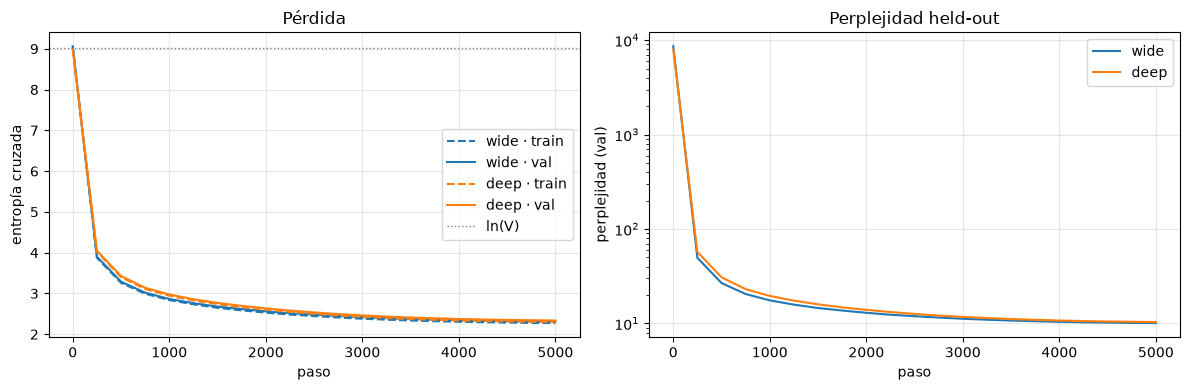

In [11]:
COLORS = {"wide": "C0", "deep": "C1"}

fig, (ax_loss, ax_ppl) = plt.subplots(1, 2, figsize=(12, 4))
for name, run in runs.items():
    steps = [h["step"] for h in run.history]
    ax_loss.plot(steps, [h["train_loss"] for h in run.history], color=COLORS[name], ls="--", label=f"{name} · train")
    ax_loss.plot(steps, [h["val_loss"] for h in run.history], color=COLORS[name], label=f"{name} · val")
    ax_ppl.plot(steps, [h["val_ppl"] for h in run.history], color=COLORS[name], label=name)

ax_loss.axhline(math.log(VOCAB_SIZE), color="0.5", ls=":", lw=1, label="ln(V)")
ax_loss.set(xlabel="paso", ylabel="entropía cruzada", title="Pérdida")
ax_ppl.set(xlabel="paso", ylabel="perplejidad (val)", title="Perplejidad held-out", yscale="log")
for ax in (ax_loss, ax_ppl):
    ax.grid(alpha=0.3)
    ax.legend()
fig.tight_layout()
fig.savefig(CKPT_DIR / "stage2_curves.png", dpi=110)
plt.show()

## Muestras a lo largo del entrenamiento

La misma semilla en todos los pasos: lo que cambia entre una muestra y la siguiente es el modelo, no el
azar. ¿En qué rango de pérdida el texto deja de ser ruido y empieza a tener forma de oración? ¿Cuándo se
sostiene un personaje a lo largo de varias oraciones?

In [12]:
for name, run in runs.items():
    val_loss_at = {h["step"]: h["val_loss"] for h in run.history}
    print("=" * 100)
    print(f"{name.upper()} · {SAMPLE_PROMPT!r}")
    for step, text in sorted(run.samples.items()):
        print(f"\n--- paso {step:,} · val loss {val_loss_at[step]:.2f} ---")
        print(SAMPLE_PROMPT + text)
    print()

WIDE · 'Once upon a time'

--- paso 0 · val loss 9.06 ---
Once upon a timeronaut mesmerdy children thornale Two incl observeDearure stirred questioned struckistertterheninarian soccer sobbed Mandy Tony ob victory relievediment vi pe sungored unw photxture businessation rolling sp pride whist vehiclesgn notes long flas materi immediately inse trunk dirt hawk� nur windy stuffed˜itingilla vegetable Johnsonhew makes attach refuseventually head fis hugging mu weekBack laugh tappedSee runp harder bathroom scored contoming blankievet Whenda hungryout tag tutor Sorry welcome� way walked Grandma tuna memory parrot Rabbit amazement hugs stair wires inchilities tickle plantingirst swoopedkay realize peanut routine spaces ignore sc Mia died rocks barking

--- paso 250 · val loss 3.90 ---
Once upon a time, theredy children, Lily were brought day on, would not a swing, but the forest.

The rabbit had a an pe Libby a unw phots business. She thought he was a picture of long. After a girl was dirt insi

## Prompts de prueba

Dos familias, para contrastar con lo que dice el paper (ancho ↔ conocimiento, profundidad ↔ contexto).
**Este set es un punto de partida: adáptenlo y defiendan sus propios prompts en el informe.**

- **Recuerdo:** completar un dato común. Se mide con decodificación *greedy* (la predicción más probable
  del modelo, no una muestra) y además con la probabilidad total que el modelo le da a las respuestas
  aceptables como próximo token, que es una medida continua y menos ruidosa que acertar o no.
- **Consistencia:** el prompt introduce un nombre y un objeto; se generan varias continuaciones (semilla
  `SEED + 100·i + j`: distinta por prompt y por muestra, idéntica entre modelos) y se mide qué fracción de
  las palabras clave vuelve a aparecer. Esto mide *mención*, no *uso correcto*: hay que leer las muestras.

In [13]:
RECALL_PROBES = [
    ("The sky is", {"blue"}),
    ("The grass is", {"green"}),
    ("At night, the moon and the", {"stars"}),
    ("The fish swam in the", {"water", "pond", "sea", "lake", "river", "ocean"}),
    ("Bees make", {"honey"}),
    ("When it rains, you need an", {"umbrella"}),
    ("Snow is cold and", {"white", "wet"}),
    ("The fire was very", {"hot"}),
    ("Birds can", {"fly", "sing"}),
    ("Apples are red and bananas are", {"yellow"}),
]

CONSISTENCY_PROBES = [
    ("Once upon a time, there was a girl named Mia. Mia had a red ball that she loved very much. One day,", ["Mia", "ball"]),
    ("Tom had a little dog named Max. Every morning, Tom and Max went to the park together. One day,", ["Tom", "Max"]),
    ("Anna found a shiny key in the garden. She wanted to know what it could open.", ["Anna", "key"]),
    ("Ben and his mom went to the beach. Ben wanted to build a big sand castle.", ["Ben", "castle"]),
    ("There was a little bird named Pip. Pip lost its blue feather in the wind.", ["Pip", "feather"]),
]
N_CONSISTENCY_SAMPLES = 2 if SMOKE_TEST else 5


def single_token_ids(words: set[str]) -> dict[str, int]:
    """Id de `Ġword` para cada respuesta que es un solo token de palabra entera; las demás se descartan."""
    ids = {w: tokenizer.token_to_id("Ġ" + w) for w in words}
    return {w: i for w, i in ids.items() if i is not None}


for prompt, answers in RECALL_PROBES:
    missing = answers - single_token_ids(answers).keys()
    if missing:
        print(f"aviso: {sorted(missing)} no es un solo token; no suma a P(respuesta) en {prompt!r}")


@torch.no_grad()
def run_recall_probes(model: GPTLanguageModel) -> pd.DataFrame:
    model.eval()
    rows = []
    for prompt, answers in RECALL_PROBES:
        idx = torch.tensor([encode_prompt(prompt)], device=DEVICE)
        logits, _ = model(idx)
        probs = F.softmax(logits[0, -1].float(), dim=-1)
        continuation = generate_text(model, prompt, max_new_tokens=6, greedy=True)
        first_word = re.findall(r"[A-Za-z]+", continuation)[:1]
        rows.append(
            {
                "prompt": prompt,
                "greedy": continuation.strip(),
                "acierto": bool(first_word) and first_word[0].lower() in answers,
                "P(respuesta)": sum(probs[i].item() for i in single_token_ids(answers).values()),
            }
        )
    return pd.DataFrame(rows)


def run_consistency_probes(model: GPTLanguageModel) -> pd.DataFrame:
    rows = []
    for i, (prompt, keywords) in enumerate(CONSISTENCY_PROBES):
        for j in range(N_CONSISTENCY_SAMPLES):
            text = generate_text(model, prompt, max_new_tokens=150, seed=SEED + 100 * i + j)
            reused = [k for k in keywords if re.search(rf"\b{re.escape(k)}s?\b", text, flags=re.IGNORECASE)]
            rows.append({"probe": i, "sample": j, "reuso": len(reused) / len(keywords), "texto": text})
    return pd.DataFrame(rows)


recall = {name: run_recall_probes(run.model) for name, run in runs.items()}
consistency = {name: run_consistency_probes(run.model) for name, run in runs.items()}

In [14]:
with pd.option_context("display.max_colwidth", 60, "display.width", 200):
    for name in runs:
        print(f"=== {name.upper()} · recuerdo ===")
        print(recall[name].to_string(index=False, float_format="{:.3f}".format))
        print()

=== WIDE · recuerdo ===
                        prompt                       greedy  acierto  P(respuesta)
                    The sky is         dark and the sky. It    False         0.045
                  The grass is             a big, red ball.    False         0.036
    At night, the moon and the moon went on a big adventure    False         0.094
          The fish swam in the       sea. He was very happy     True         0.613
                     Bees make       a big tower with a big    False         0.001
    When it rains, you need an         idea. It will be fun    False         0.042
              Snow is cold and       cold. He does not like    False         0.096
             The fire was very    hot and the fire was very     True         0.186
                     Birds can      make a big, strong wind    False         0.079
Apples are red and bananas are    very pretty. They like to    False         0.021

=== DEEP · recuerdo ===
                        prompt        

In [15]:
for i, (prompt, keywords) in enumerate(CONSISTENCY_PROBES):
    print("=" * 100)
    print(f"[{i}] {prompt}   (palabras clave: {', '.join(keywords)})")
    for name in runs:
        first = consistency[name].query("probe == @i and sample == 0").iloc[0]
        print(f"\n--- {name} · reuso {first['reuso']:.0%} ---")
        print(first["texto"].strip())
    print()

[0] Once upon a time, there was a girl named Mia. Mia had a red ball that she loved very much. One day,   (palabras clave: Mia, ball)

--- wide · reuso 100% ---
Mia and her friend, Lily, brought a purple ball would catch it. Daisy wanted to catch the ball too, but Sam said no. Mia was afraid of playing with the ball and he didn't want the long.

Mia's friend, Sam, saw them and they were too fast, but they were too big and too slow. But Mia didn't run away harder, and Sam thought of something was wrong. He got angry and yelled at Mia, and said, "Stop it. You must behave when you get back." Mia didn't listen and ran away from Mia.

Sam and Mia ran to the park. They had an idea. They called for lunch and hid away in their small house. They were not grumpy anymore

--- deep · reuso 100% ---
Mia and her friend, Jack were playing in the park. Mia noticed the ball and took it out of it. Jack had a ball that Mia was unwrab businessation and she wanted to join in the park.

Mia's friend, Sam, s

## La tabla de la ablación

In [16]:
ablation = pd.DataFrame(
    {
        name: {
            "n_embd": run.model.cfg.n_embd,
            "n_layer": run.model.cfg.n_layer,
            "parámetros (M)": count_params(run.model)["total"] / 1e6,
            "train loss": run.history[-1]["train_loss"],
            "val loss": run.history[-1]["val_loss"],
            "val ppl": run.history[-1]["val_ppl"],
            "recuerdo: aciertos greedy": recall[name]["acierto"].mean(),
            "recuerdo: P(respuesta) media": recall[name]["P(respuesta)"].mean(),
            "consistencia: reuso medio": consistency[name]["reuso"].mean(),
            "minutos de entrenamiento": run.history[-1]["elapsed_s"] / 60,
        }
        for name, run in runs.items()
    }
)
ablation.to_csv(CKPT_DIR / "stage2_ablation.csv")
print(ablation.to_string(float_format="{:.3f}".format))

                                wide    deep
n_embd                       256.000 192.000
n_layer                        2.000   5.000
parámetros (M)                 5.847   5.425
train loss                     2.273   2.297
val loss                       2.311   2.336
val ppl                       10.081  10.340
recuerdo: aciertos greedy      0.200   0.200
recuerdo: P(respuesta) media   0.121   0.101
consistencia: reuso medio      0.520   0.580
minutos de entrenamiento       6.343   8.521


## ¿Cuántos datos vieron, contra el óptimo de Chinchilla?

Hoffmann et al. (2022) estiman que, para un presupuesto de cómputo fijo, lo óptimo es entrenar con
≈ 20 tokens por parámetro. Kaplan et al. (2020) cuentan los parámetros *sin* embeddings (en sus modelos la
salida comparte la matriz de embeddings); acá eso equivale a sacar embeddings y `lm_head`, y con este
vocabulario la diferencia entre las dos cuentas es grande, así que se muestran ambas.

In [17]:
for name, run in runs.items():
    counts = count_params(run.model)
    n_total = counts["total"]
    n_core = counts["bloques Transformer"]
    seen = run.history[-1]["tokens_seen"]
    print(f"{name}: {seen / 1e6:.1f}M tokens vistos ({seen / len(train_ids):.2f} épocas)")
    for label, n in (("N total", n_total), ("N sin embeddings ni lm_head", n_core)):
        print(f"    {label:<28} {n / 1e6:5.2f}M → 20·N = {20 * n / 1e6:4.0f}M tokens · vistos / óptimo = {seen / (20 * n):.2f}")

wide: 81.9M tokens vistos (0.93 épocas)
    N total                       5.85M → 20·N =  117M tokens · vistos / óptimo = 0.70
    N sin embeddings ni lm_head   1.58M → 20·N =   32M tokens · vistos / óptimo = 2.60
deep: 81.9M tokens vistos (0.93 épocas)
    N total                       5.42M → 20·N =  108M tokens · vistos / óptimo = 0.76
    N sin embeddings ni lm_head   2.22M → 20·N =   44M tokens · vistos / óptimo = 1.84


## Para el informe

- ¿En qué rango de pérdida el texto deja de ser ruido y empieza a tener estructura de oración? (Cruzar las
  muestras con las curvas.)
- ¿El par ancho/profundo reproduce lo que encontró el paper (ancho ↔ conocimiento, profundidad ↔
  contexto)? Si no, ¿cuál es la mejor explicación: escala, cuánto entrenaron, cómo diseñaron los prompts?
- ¿Qué tuvieron que recortar para que la ablación entrara en la máquina que tenían, y qué habrían medido
  con más?
- Contra Chinchilla, ¿dónde quedaron parados y qué creen que les costó?

Lo que sigue: Etapa 3 (`03_embeddings.py`) — la tabla de embeddings de `pretrain_wide.pt` contra la de
`pretrain_step0.pt`.

## Informe y conclusiones de la Etapa 2

Este informe interpreta la corrida completa guardada en este notebook (el log de entrenamiento de cada modelo está en su celda) y su tabla de ablación. A lo largo del informe distinguimos estructura de oración de coherencia, menciones de uso correcto del contexto y resultados medidos de posibles explicaciones.

### Respuestas conceptuales

**¿Cuándo deja de ser ruido?** Las primeras frases reconocibles aparecen con una pérdida de validación de aproximadamente **4,0 a 3,3**. En el paso 0, con pérdida cercana a 9, ambos modelos mezclan palabras y fragmentos sin conexión. A los 250–500 pasos aparecen estructuras de oración y frases como “She was happy.”, todavía rodeadas de errores. Entre pérdidas de **3,0 y 2,6** vemos más organización narrativa y, desde el paso 2.000, ambos sostienen el nombre Lily. Sin embargo, al terminar en **2,311 y 2,336** siguen confundiendo acciones, objetos y pronombres. La estructura local aparece antes que la consistencia; no encontramos un umbral que garantice cuentos coherentes ni gramática completamente estabilizada.

**¿Se reproduce ancho–conocimiento y profundidad–contexto?** Solo encontramos indicios parciales. Ambos modelos aciertan **2 de 10** prompts de recuerdo, aunque el ancho asigna más probabilidad media a las respuestas admitidas: **0,121 frente a 0,101**. El profundo obtiene más reuso de palabras clave, **0,58 frente a 0,52**, pero los textos muestran que repetir nombres no implica conservar identidades. La escala, el entrenamiento todavía en progreso y el diseño de los prompts podrían explicar la falta de una diferencia clara; no los identificamos como causas demostradas. Una sola semilla y pocos casos no permiten confirmar el paper ni declarar una superioridad general.

**¿Qué se recortó?** Se utilizaron 400.000 cuentos, dos configuraciones de unos 5–6 millones de parámetros, contexto de 256 tokens y 5.000 pasos por modelo. Se mantuvo la ablación, pero no se exploraron varias semillas, más arquitecturas ni una evaluación amplia. La corrida registrada usó una RTX 5070 Laptop con aproximadamente 8 GB de VRAM, precisión mixta y almacenamiento del corpus en `uint16` para reducir memoria. No consta que un fallo de memoria impusiera ese presupuesto. **El límite fue el tiempo, no la memoria.** El trabajo del grupo se concentró en los tres días previos a la entrega, y queríamos que esta etapa corriera en minutos para dejar lugar a las Etapas 3 a 5: el ancho tardó 6,3 minutos y el profundo 8,5. Con 5.000 pasos × 64 ventanas × 256 tokens = 81,9 millones de tokens, 400.000 cuentos (88,5 millones) alcanzan para que cada modelo procese menos tokens de los que tiene el corpus (0,93 épocas): casi no ve dos veces lo mismo, y la brecha entre entrenamiento y validación queda en 0,04. Corrimos en la notebook con la RTX 5070 y no en Colab porque así el pipeline entero tardaba poco más de media hora, sin depender de sesiones que se cortan ni de montar Drive para no perder los checkpoints; los notebooks siguen preparados para Colab (primera celda). El registro de decisiones del proyecto está al final del notebook `00_dataset`. Con más recursos priorizaríamos repeticiones y mejores pruebas de contexto antes de aumentar el tamaño.

**¿Dónde quedamos frente a Chinchilla?** Había **88,53 millones de tokens disponibles** en entrenamiento, pero cada modelo procesó **81,92 millones**: 5.000 pasos × 64 ventanas × 256 tokens. Las ventanas aleatorias pueden repetirse, por lo que el equivalente a 0,93 épocas no representa un recorrido ordenado del 93 % del corpus. Los tokens de validación no se usan para actualizar parámetros.

Contando todos los parámetros, procesamos aproximadamente **14,0 tokens por parámetro en el ancho y 15,1 en el profundo**. Eso representa el **70 % y 76 %** de la referencia de 20 tokens por parámetro. Podría haber quedado capacidad sin aprovechar, pero no podemos cuantificar cuánto rendimiento faltó. Si contamos solo los bloques, lo procesado equivale a **2,60 y 1,84 veces** esa referencia. El cambio se debe al enorme peso de embeddings y salida, no a que el mismo entrenamiento sea simultáneamente insuficiente y excesivo. La categoría “bloques” también excluye posiciones y normalización final. La regla es orientativa: Chinchilla estudia otras escalas y presupuestos, y superar ese cociente no demuestra sobreajuste ni desperdicio. [Hoffmann et al., 2022](https://arxiv.org/abs/2203.15556).

### Diseño y comparación de los modelos

**El experimento, en corto.** *Hipótesis* (la del paper): con una cantidad de parámetros parecida, el modelo ancho debería recordar mejor datos comunes y el profundo sostener mejor, varias oraciones después, lo que apareció antes en el cuento. *Qué variamos:* solo el ancho del residual y la cantidad de capas (256 × 2 contra 192 × 5; las cabezas pasan de 8 a 6 para que cada una siga teniendo 32 dimensiones). *Qué dejamos fijo:* tokenizador, datos, orden de los batches, semilla, contexto, optimizador y presupuesto de pasos, detallados abajo. *Cómo lo medimos:* pérdida y perplejidad sobre `validation`, diez prompts de recuerdo (acierto greedy y probabilidad de la respuesta), cinco prompts de consistencia con cinco muestras cada uno, y la lectura de las muestras. Contamos los parámetros antes de entrenar: el profundo tiene un 7,2 % menos en total, pero un 41 % más en los bloques.

El modelo aprende a predecir el próximo token a partir de los anteriores. El BPE de la Etapa 1 define las **8.192 unidades** con las que representamos el texto; el preentrenamiento aprende sus combinaciones y dependencias. La pérdida recompensa acertar el siguiente token, sin evaluar directamente si la historia completa tiene sentido.

Cada cuento termina con `<|endoftext|>` y se concatena con el siguiente. El delimitador señala límites y puede detener la generación, pero no impide atender al cuento anterior dentro de una ventana. Elegimos 256 tokens porque el **90,2 %** de los cuentos medidos en la Etapa 1 cabía por longitud, frente al 60,4 % con 192. Ese porcentaje se midió sobre cuentos de `validation`, y los de `train` son algo más largos (221 tokens por cuento contra 201, contando el `<|endoftext|>`, según la tokenización de arriba): entre los datos de entrenamiento, la fracción que entra es menor. Además, las ventanas comienzan al azar: pueden cortar cuentos o mezclar el final de uno con el principio de otro.

Los modelos comparten datos, orden de batches, semilla 1337, contexto, dropout de 0,1 y presupuesto. Usan AdamW, calentamiento de 100 pasos, tasa de aprendizaje de 3e-4 con descenso coseno hasta 3e-5, weight decay de 0,1 sobre matrices y recorte de gradiente de 1,0. La validación utiliza un split separado y 50 batches fijos por evaluación, sin dropout, para comparar la evolución sobre las mismas ventanas.

| Configuración o resultado | Ancho | Profundo |
|---|---:|---:|
| Dimensión / capas | 256 / 2 | 192 / 5 |
| Cabezas × dimensión por cabeza | 8 × 32 | 6 × 32 |
| Parámetros totales | 5.846.528 | 5.424.896 |
| Embeddings de tokens y posiciones | 2.162.688 | 1.622.016 |
| Bloques Transformer | 1.577.984 | 2.221.440 |
| Salida y normalización final | 2.105.856 | 1.581.440 |
| Pérdida de entrenamiento | 2,273 | 2,297 |
| Pérdida de validación | 2,311 | 2,336 |
| Perplejidad de validación | 10,08 | 10,34 |
| Recuerdo: aciertos greedy | 2/10 | 2/10 |
| Recuerdo: probabilidad media admitida | 0,121 | 0,101 |
| Reuso de palabras clave | 0,52 | 0,58 |
| Tiempo registrado | 6,34 min | 8,52 min |

Embeddings y salida no comparten pesos: sus matrices principales crecen como vocabulario × ancho, mientras que los bloques crecen aproximadamente como capas × ancho². Por eso reducir el ancho a la mitad y duplicar las capas no conserva parámetros. Nuestro profundo tiene **7,2 % menos parámetros totales**, pero **41 % más en los bloques**. Embeddings y salida concentran aproximadamente el 73 % del ancho y el 59 % del profundo: también cambia dónde se distribuye la capacidad.

Igualar pasos y tokens tampoco iguala costo: el profundo tardó aproximadamente **34 % más**. El tiempo registrado incluye evaluaciones y tareas intercaladas, no solo actualizaciones. El ancho obtiene una ventaja de **0,025 en pérdida de validación** y aproximadamente **2,5 % en perplejidad**, válida para esta corrida, sin demostrar superioridad general.

### Curvas y muestras: qué mejora y qué falta

La entropía cruzada penaliza asignar poca probabilidad al token correcto; la **perplejidad = exp(pérdida)** expresa esa misma medición en otra escala. Los valores iniciales, 9,063 y 8,988, están cerca de ln(8.192) ≈ 9,01, la referencia de una predicción uniforme. A los 500 pasos, las perplejidades ya bajan a 26,8 y 30,8. Después las mejoras se vuelven menores.

La distancia final entre entrenamiento y validación es de aproximadamente **0,038–0,039**. No vemos una subida de validación mientras entrenamiento sigue bajando: no hay una señal clara de sobreajuste en estas curvas. Tampoco demostramos convergencia. Comparando el mismo tramo, del paso 4.250 al 5.000, validación baja **0,020 en el ancho y 0,025 en el profundo**. Ambos seguían mejorando; la desaceleración también coincide con la reducción programada de la tasa de aprendizaje.

Las muestras permiten interpretar esa mejora sin confundirla con calidad narrativa:

- **Paso 500:** el ancho combina “She was happy.” con “Jane was a would go home.”. El profundo escribe “a little girl named she loved to play”: reconoce una fórmula, pero no completa correctamente el nombre.
- **Paso 1.000:** aparecen oraciones como “She saw a big trunk and melted.” en el ancho y “she saw a voice” en el profundo. La estructura mejora antes que el sentido.
- **Paso 2.000:** ambos conservan a Lily, pero el ancho cierra con “promised to never peanut on things again” y el profundo con “she went to play together and died.”. Aprender una fórmula de cierre no equivale a resolver la historia.
- **Paso 5.000:** el ancho mantiene muñecas y ropa, pero introduce referencias ambiguas y “she put it on harder”. El profundo hace que un búho llame “bird” a Lily y luego confunde pronombres. Los finales truncados deben interpretarse considerando el límite de **120 tokens nuevos**: un corte no demuestra por sí solo incapacidad para terminar.

La semilla fija controla el muestreo, pero una trayectoria no representa toda la calidad del modelo. Palabras como “harder” o “peanut” reaparecen entre muestras; compartir el generador aleatorio puede contribuir, aunque no probamos esa causa. También observamos `â€œ` en una continuación. La Etapa 1 midió que el 6 % de los cuentos held-out tiene texto mal codificado de esa misma familia (`â€`: el `’` guardado como `â€™`, el `“` como `â€œ`), así que lo más probable es que el modelo lo haya aprendido del corpus; no rastreamos qué cuentos de entrenamiento lo originan.

### Qué miden realmente los prompts

En recuerdo, **greedy** elige el token más probable y se verifica la primera palabra generada. La probabilidad admitida suma, en cambio, la masa de los tokens aceptados como respuesta inmediata. El ancho acierta pez → “sea” y fuego → “hot”; el profundo, pez → “pond” y aves → “fly”. La probabilidad permite distinguir asociaciones que el empate 2/10 oculta: para fuego da **0,186 frente a 0,058**, mientras que para aves favorece al profundo, **0,245 frente a 0,079**.

El conjunto de respuestas condiciona el resultado: para el pez se admiten seis palabras, pero para el cielo solo “blue”, por lo que “dark” cuenta como error aunque sea posible. La probabilidad solo contempla respuestas de un token con espacio inicial. Además, los prompts son fragmentos de texto presentados como inicio de cuento, no preguntas explícitas. La métrica mide esas continuaciones y respuestas admitidas, no conocimiento factual general.

En consistencia hay **cinco prompts × cinco muestras = 25 generaciones por modelo**, no 25 prompts diferentes. Con dos palabras clave, el reuso equivale a **26 frente a 29 menciones sobre 50 posibles**. Se cuenta presencia al menos una vez, sin exigir reaparición tardía o uso correcto. Las salidas impresas muestran la primera generación de cada prompt; bastan para detectar límites de la métrica:

- Ambos alcanzan 100 % con Mia y la pelota, aunque el ancho termina haciendo que Mia huya de Mia.
- El profundo logra 100 % con Tom y Max mientras escribe “Hi, I'm Tom,” Max said: repetir ambos nombres encubre una confusión de identidad.
- Ambos mencionan a Ben y el castillo, pero las acciones se desvían hacia objetos desconectados. En el caso de Pip y la pluma, ambos abandonan las palabras clave.

También podría haber continuidad correcta mediante pronombres sin repetir un nombre. Por eso el reuso puede premiar incoherencias y penalizar continuidades válidas. La diferencia de tres menciones es una tendencia descriptiva; no estimamos significancia ni variabilidad entre corridas.

Como evidencia complementaria, el juez de la Etapa 5 da consistencia **2,17 al ancho y 1,96 al profundo**, en dirección opuesta al reuso. Evalúa **24 textos por modelo, con otros prompts y generaciones**, y presenta un efecto piso en gramática: tampoco es una medida definitiva. Sus perplejidades, **10,32 y 10,58**, corresponden a otra evaluación con otros batches; no reemplazan las **10,08 y 10,34** de esta etapa ni indican entrenamiento adicional de los modelos base.

### Conclusión y experimento pendiente

El resultado central es que **mejorar la predicción local puede convivir con historias incoherentes**. En validación el modelo recibe contexto real; al generar, continúa sus propias decisiones y errores. Puede conservar frases típicas y nombres mientras pierde quién posee un objeto o por qué ocurre una acción. Los ejemplos de Mia y Max muestran por qué una métrica de repetición da una impresión engañosa de memoria.

Podemos sostener que ambos modelos aprendieron estructura lingüística y que el ancho obtuvo una pequeña ventaja predictiva con menor tiempo de ejecución. Sigue abierto si la profundidad favorece el contexto bajo más entrenamiento y una evaluación adecuada.

**Como experimento futuro**, repetiríamos el par con al menos tres semillas y relatos que introduzcan una relación explícita —quién guarda una llave y dónde—. Evaluaríamos su recuperación tras 32, 64 y 128 tokens, controlando el texto intermedio y manteniéndolo dentro del contexto. Combinaríamos aciertos, probabilidades y lectura de continuaciones. Así podríamos medir si la ventaja depende de la distancia al dato y se sostiene entre corridas. Esta prueba está propuesta, no realizada.